In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


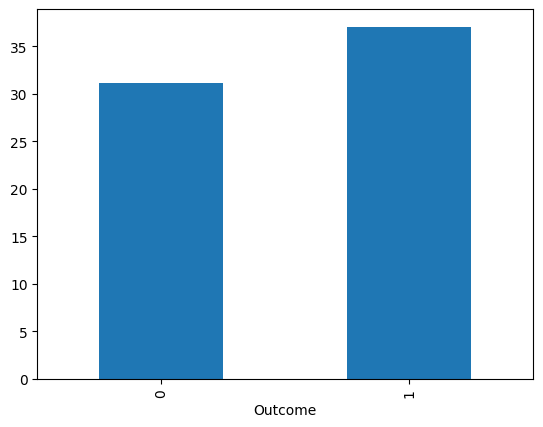

In [ ]:
df.groupby('Outcome')['Age'].mean().plot(kind='bar');

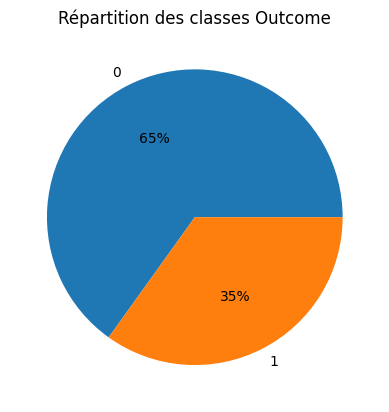

In [ ]:
df['Outcome'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    ylabel=''
)
plt.title('Répartition des classes Outcome');

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

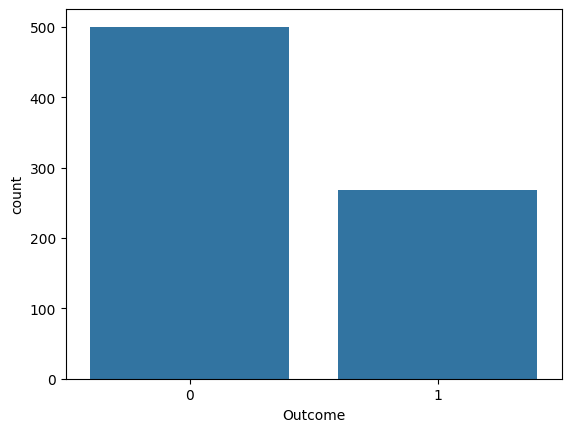

In [ ]:
sns.countplot(x='Outcome', data=df);

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#NN

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [ ]:
class_weights = dict(enumerate(class_weights))

In [ ]:
scaler = MinMaxScaler()

In [ ]:
scale_X_train = scaler.fit_transform(X_train)
scale_X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
stop = EarlyStopping(monitor='val_loss', mode='auto', verbose=1, patience=10)

In [ ]:
model.fit(scale_X_train, y_train, epochs=100,
          validation_data=(scale_X_test, y_test),
          callbacks=[stop], class_weight=class_weights)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5240 - loss: 0.8914 - val_accuracy: 0.3571 - val_loss: 0.7085
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6928 - loss: 0.6701 - val_accuracy: 0.3766 - val_loss: 0.6997
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6969 - loss: 0.6219 - val_accuracy: 0.3831 - val_loss: 0.7008
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7156 - loss: 0.5676 - val_accuracy: 0.4416 - val_loss: 0.6945
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7406 - loss: 0.5137 - val_accuracy: 0.4805 - val_loss: 0.6922
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6924 - loss: 0.6142 - val_accuracy: 0.4805 - val_loss: 0.6882
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7320 - loss: 0.5661 - val_accuracy: 0.4805 - val_loss: 0.6869
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7085 - loss: 0.5693 - val_accuracy: 0.4805 

In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,341 (134.15 KB)

 Trainable params: 11,297 (44.13 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 22,596 (88.27 KB)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
y_prod = model.predict(scale_X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
y_pred = np.argmax(y_prod, axis=1)

In [ ]:
round(accuracy_score(y_test, y_pred), 2)

0.65

In [ ]:
confusion_matrix(y_test, y_pred)

array([[71, 29],
       [14, 40]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.71      0.77       100
           1       0.58      0.74      0.65        54

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154



#SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = SVC(class_weight='balanced')

In [ ]:
svc.fit(scale_X_train, y_train)

SVC(class_weight='balanced')

In [ ]:
y_pred = svc.predict(scale_X_test)

In [ ]:
round(accuracy_score(y_test, y_pred), 2)

0.72

In [ ]:
confusion_matrix(y_test, y_pred)

array([[71, 29],
       [14, 40]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.71      0.77       100
           1       0.58      0.74      0.65        54

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154



#Regression logistique

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression(class_weight='balanced')

In [ ]:
lr.fit(scale_X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred = lr.predict(scale_X_test)

In [ ]:
round(accuracy_score(y_test, y_pred), 2)

0.75

In [ ]:
confusion_matrix(y_test, y_pred)

array([[75, 25],
       [15, 39]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



#Forêt aléatoire

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(class_weight='balanced')

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [ ]:
y_pred = rfc.predict(X_test)

In [ ]:
round(accuracy_score(y_test, y_pred), 2)

0.75

In [ ]:
confusion_matrix(y_test, y_pred)

array([[83, 17],
       [21, 33]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



#XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(is_unbalance=True)

In [ ]:
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:02:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "is_unbalance" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              is_unbalance=True, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [ ]:
y_pred = xgb.predict(X_test)

In [ ]:
round(accuracy_score(y_test, y_pred), 2)

0.73

In [ ]:
confusion_matrix(y_test, y_pred)

array([[80, 20],
       [21, 33]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



#LigthGBM

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lgbm = LGBMClassifier(is_unbalance=True)

In [ ]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(is_unbalance=True)

In [ ]:
y_pred = lgbm.predict(X_test)

In [ ]:
round(accuracy_score(y_test, y_pred), 2)

0.74

In [ ]:
confusion_matrix(y_test, y_pred)

array([[79, 21],
       [19, 35]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       100
           1       0.62      0.65      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [ ]:
feature = pd.DataFrame(lgbm.feature_importances_, index=X_train.columns, columns=['Importance']).sort_values('Importance', ascending=False)

In [ ]:
feature

,Importance
DiabetesPedigreeFunction,500
Glucose,434
BMI,403
Age,316
BloodPressure,264
Pregnancies,206
SkinThickness,182
Insulin,169


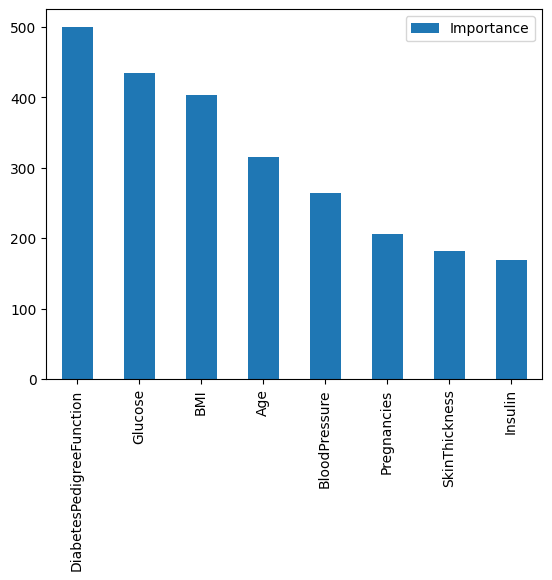

In [ ]:
feature.plot(kind='bar');

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(lgbm)

In [ ]:
shap_values = explainer.shap_values(X_test)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


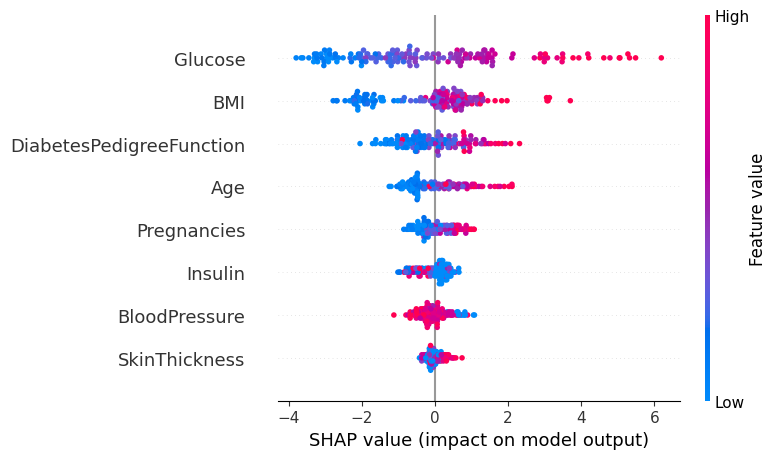

In [ ]:
shap.summary_plot(shap_values, X_test)

#Test

In [ ]:
test = X_test.iloc[24]

In [ ]:
test = test.values.reshape(1, -1)

In [ ]:
rfc.predict(test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
y_test.iloc[24]

np.int64(0)